#  – Comparative Clustering
**Thuật toán:** K-Means · Hierarchical · DBSCAN · Spectral  
Trực quan cụm 2D, 3D


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import KernelPCA, PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import scipy.cluster.hierarchy as sch

sns.set_theme(style="whitegrid")


## 1. Load dữ liệu · PCA


In [ ]:
df_raw = pd.read_csv('pipeline_P6_scaled.csv')

(array([  13.,   13.,   53.,  245.,  688., 1430., 1519.,  771.,  288.,
          69.]),
 array([-1.        , -0.84218112, -0.68436224, -0.52654337, -0.36872449,
        -0.21090561, -0.05308673,  0.10473215,  0.26255102,  0.4203699 ,
         0.57818878]),
 <BarContainer object of 10 artists>)

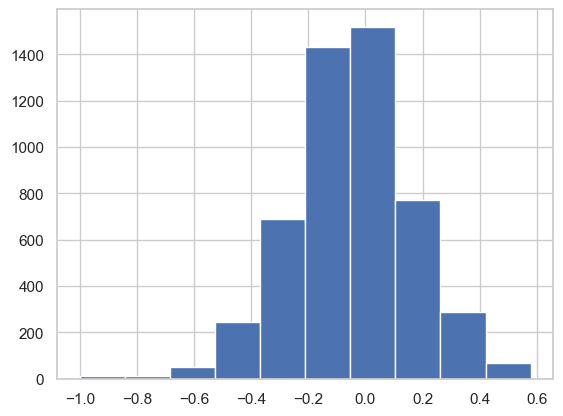

In [22]:
plt.hist(df_raw['burstiness_recent'])

In [ ]:


handle_col = df_raw['handleName']

df = df_raw.drop(columns=['handleName'])




Số chiều sau PCA: 7


In [ ]:
pca = PCA(n_components=0.95)
X_model = pca.fit_transform(df)
print(f"Số chiều sau PCA: {X_model.shape[1]}")

In [23]:
loading_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df.columns
)

print(loading_df)


                                       PC1       PC2       PC3       PC4  \
followerCnt                      -0.006199  0.008137  0.003360 -0.028590   
startingRate100k                 -0.015724  0.004317  0.005364 -0.005352   
recommendRate100k                 0.010947  0.010519  0.002452 -0.037892   
followersGrowthRateRank           0.602485 -0.048218  0.794923  0.037485   
avgSixSecondsViewsRateRank        0.000496 -0.000143 -0.000481  0.000147   
medianViewsRank                   0.099693 -0.023260 -0.038095  0.036416   
videoCompleteRateRank             0.000535 -0.000205 -0.000477  0.000148   
engagementRateRank               -0.029999 -0.000033  0.004125  0.151207   
avgSixSecondsViewsBenchMarkViews  0.758633 -0.232087 -0.595869  0.035830   
medianBenchMarkViews              0.009828  0.005353 -0.001496 -0.032838   
engagementRateBenchMark          -0.079926 -0.121833  0.008408  0.970051   
followersGrowthRate               0.004890  0.009813 -0.005487 -0.033340   
avgSixSecond

In [24]:
for pc in loading_df.columns:
    print(f"\n{pc}")
    
    top_features = (
        loading_df[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )
    
    print(top_features)


PC1
avgSixSecondsViewsBenchMarkViews    0.758633
followersGrowthRateRank             0.602485
country_ID                          0.205514
medianViewsRank                     0.099693
engagementRateBenchMark             0.079926
avgSixSecondsViewsRate              0.031254
engagementRateRank                  0.029999
startingRate100k                    0.015724
recommendRate100k                   0.010947
medianBenchMarkViews                0.009828
Name: PC1, dtype: float64

PC2
country_ID                          0.961059
avgSixSecondsViewsBenchMarkViews    0.232087
engagementRateBenchMark             0.121833
country_PH                          0.052370
followersGrowthRateRank             0.048218
medianViewsRank                     0.023260
country_TW                          0.021631
country_TH                          0.016341
avgSixSecondsViewsRate              0.014942
country_JP                          0.014207
Name: PC2, dtype: float64

PC3
followersGrowthRateRank          

followersGrowthRateRank 

## 2. K-Means

### 2a. Elbow Method – WCSS (k = 1 → 10)

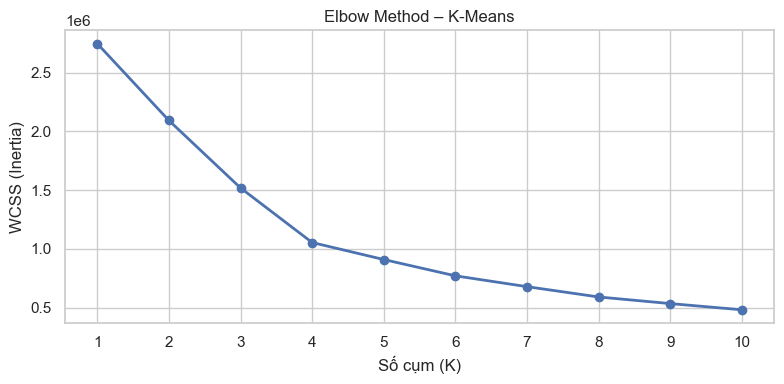

In [3]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_model)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), wcss, marker='o', linewidth=2)
plt.xlabel('Số cụm (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method – K-Means')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


### 2b. Silhouette Score (k = 2 → 10) – chọn k có score cao nhất

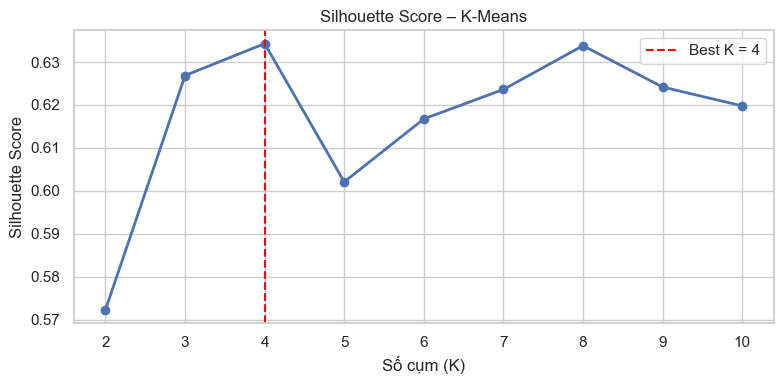

K tối ưu (Silhouette): 4


In [4]:
K_sil = range(2, 11)
sil_km = []
for k in K_sil:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_model)
    sil_km.append(silhouette_score(X_model, labels))

best_k_km = list(K_sil)[int(np.argmax(sil_km))]

plt.figure(figsize=(8, 4))
plt.plot(list(K_sil), sil_km, marker='o', linewidth=2)
plt.axvline(best_k_km, color='red', linestyle='--', label=f'Best K = {best_k_km}')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score – K-Means')
plt.legend()
plt.tight_layout()
plt.show()
print(f"K tối ưu (Silhouette): {best_k_km}")


### 2c. Fit K-Means với k tối ưu

In [5]:
K_KMEANS     = best_k_km   # ← ghi đè thủ công nếu muốn
kmeans       = KMeans(n_clusters=K_KMEANS, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_model)
print(f"K-Means fitted với K = {K_KMEANS}")


# ── K-Means với K = 8 ─────────────────────────────────────────────────────
kmeans_8      = KMeans(n_clusters=8, random_state=42, n_init=10)
print("K-Means fitted với K = 8")
labels_kmeans_8 = kmeans_8.fit_predict(X_model)

K-Means fitted với K = 4
K-Means fitted với K = 8


## 3. Hierarchical Clustering (Ward)

### 3a. Dendrogram

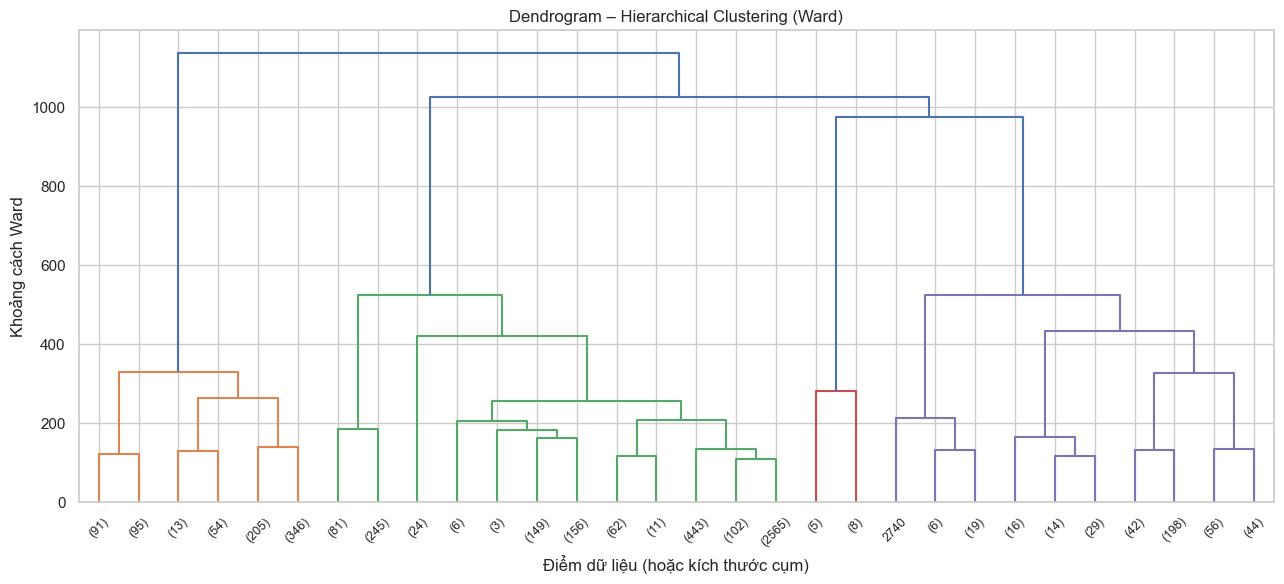

In [6]:
plt.figure(figsize=(13, 6))
sch.dendrogram(
    sch.linkage(X_model, method='ward'),
    truncate_mode='lastp', p=30,
    leaf_rotation=45, leaf_font_size=9
)
plt.title('Dendrogram – Hierarchical Clustering (Ward)')
plt.xlabel('Điểm dữ liệu (hoặc kích thước cụm)')
plt.ylabel('Khoảng cách Ward')
plt.tight_layout()
plt.show()


### 3b. Fit Hierarchical với k tối ưu

In [ ]:
K_HC    = 4      
hc_model = AgglomerativeClustering(n_clusters=K_HC, linkage='ward')
labels_hc = hc_model.fit_predict(X_model)
print(f"Hierarchical fitted với K = {K_HC}")


Hierarchical fitted với K = 4


## 4. DBSCAN – Grid Search tìm tham số tối ưu

### 4a. Grid Search (eps × min_samples) – tối đa hoá Silhouette Score

In [ ]:
# ── Grid rộng để đảm bảo tìm được cấu hình hợp lệ ───────────────────────
eps_grid         = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]
min_samples_grid = [3, 5, 7, 9, 11, 15]
NOISE_RATIO_MAX  = 0.6   # ← cho phép tối đa 60% noise, tăng nếu cần

best_db_score  = -1
best_db_params = {}
records_db     = []

for eps, ms in product(eps_grid, min_samples_grid):
    labels  = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_model)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    noise_ratio = n_noise / len(labels)

    if n_clust >= 2 and noise_ratio < NOISE_RATIO_MAX:
        score = silhouette_score(X_model, labels)
        records_db.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clust, 'n_noise': n_noise,
            'noise_pct': round(noise_ratio * 100, 1),
            'silhouette': round(score, 4)
        })
        if score > best_db_score:
            best_db_score  = score
            best_db_params = {'eps': eps, 'min_samples': ms}

if not records_db:
    print("⚠️  Không tìm được cấu hình DBSCAN hợp lệ!")
    print("   → Thử tăng NOISE_RATIO_MAX hoặc mở rộng eps_grid / min_samples_grid")
    best_db_params = {'eps': eps_grid[len(eps_grid)//2],
                      'min_samples': min_samples_grid[0]}
else:
    df_db_grid = pd.DataFrame(records_db).sort_values('silhouette', ascending=False)
    print(df_db_grid.head(10).to_string(index=False))
    print(f"\nTham số tối ưu: eps={best_db_params['eps']}, "
          f"min_samples={best_db_params['min_samples']}, "
          f"Silhouette={best_db_score:.4f}")



 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
10.0            7           2      148        2.9      0.6923
10.0            9           2      166        3.3      0.6886
10.0           11           2      170        3.3      0.6874
10.0           15           2      184        3.6      0.6843
10.0            3           7       86        1.7      0.6808
 8.0            7           2      216        4.2      0.6736
 8.0           11           2      242        4.8      0.6713
 8.0            5           3      194        3.8      0.6629
 8.0           15           2      280        5.5      0.6608
10.0            5           4      118        2.3      0.6591

Tham số tối ưu: eps=10.0, min_samples=7, Silhouette=0.6923


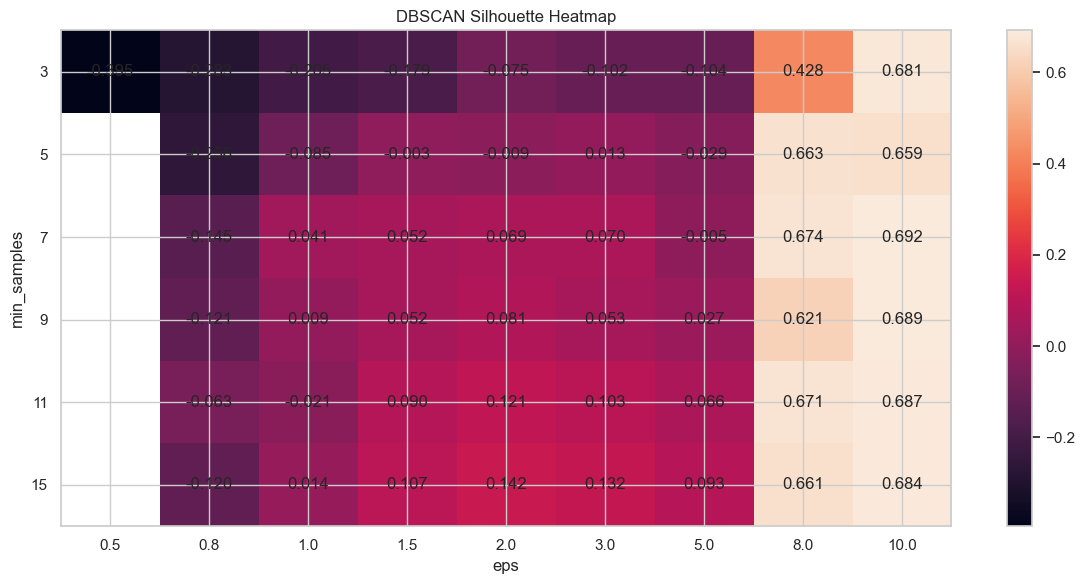

In [30]:
heatmap_data = df_db_grid.pivot(
    index='min_samples',
    columns='eps',
    values='silhouette'
)

# Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ heatmap
im = ax.imshow(
    heatmap_data.values,
    aspect='auto'
)

# Tick labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Label
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
ax.set_title("DBSCAN Silhouette Heatmap")

# Hiện số trong từng ô
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha='center',
                va='center'
            )

# Color bar
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [10]:
# df_db_grid.sort_values('eps', ascending=False)

### 4b. Fit DBSCAN với tham số tối ưu

In [11]:
dbscan    = DBSCAN(eps=best_db_params['eps'],
                   min_samples=best_db_params['min_samples'])
labels_db = dbscan.fit_predict(X_model)

n_clust = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = int(np.sum(labels_db == -1))
print(f"Số cụm: {n_clust} | Noise points: {n_noise}")


# ── DBSCAN với eps=10, min_samples=3 ─────────────────────────────────────

dbscan_7 = DBSCAN(eps=10, min_samples=3)
labels_db_7 = dbscan_7.fit_predict(X_model)

n_noise_7 = int(np.sum(labels_db_7 == -1))
n_clust_7 = len(set(labels_db_7)) - (1 if -1 in labels_db_7 else 0)

print(f"Số cụm = {n_clust_7} | Noise points = {n_noise_7}")

Số cụm: 2 | Noise points: 148
Số cụm = 7 | Noise points = 86


## 5. Spectral Clustering – Ma trận Silhouette Score

### 5a. Grid Search: k × sigma × k_nn  
`k_clusters` = 2–6 · `sigma` = [0.3, 0.5, 0.7, 1.0] · `k_nn` = [5, 10, 15]

In [12]:
# Tìm k_nn nhỏ nhất mà fully connected
import warnings
for k_nn in [10, 15, 20, 30, 50]:
    sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors',
                            n_neighbors=k_nn, random_state=42)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        sc.fit_predict(X_model)
        connected = len(w) == 0
    print(f"k_nn={k_nn:3d} → {'✓ connected' if connected else '✗ not connected'}")

k_nn= 10 → ✗ not connected
k_nn= 15 → ✗ not connected
k_nn= 20 → ✗ not connected
k_nn= 30 → ✓ connected
k_nn= 50 → ✓ connected


In [34]:
#  dùng affinity='nearest_neighbors' (sparse) + subsample grid search.

import time

k_clusters_grid = range(2, 7)       # k = 2, 3, 4, 5, 6
k_nn_grid       = [30,40,45,50,55,60]   # số láng giềng cho nearest_neighbors affinity

# ── Subsample để grid search nhanh ───────────────────────────────────────
SUBSAMPLE_N = 5089    # ← tăng nếu dataset nhỏ hơn 2000; giảm nếu vẫn chậm
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X_model), size=min(SUBSAMPLE_N, len(X_model)), replace=False)
X_sub   = X_model[idx_sub]
print(f"Grid search trên {len(X_sub)} mẫu (/{len(X_model)} tổng)")

records_sc = []
t0 = time.time()

for k_nn in k_nn_grid:
    row = {'k_nn': k_nn}
    for k in k_clusters_grid:
        try:
            sc     = SpectralClustering(
                         n_clusters  = k,
                         affinity    = 'nearest_neighbors',  # sparse – nhanh hơn rbf rất nhiều
                         n_neighbors = k_nn,
                         n_jobs      = -1,                   # dùng toàn bộ CPU
                         random_state = 42,
                         n_init      = 10
                     )
            labels = sc.fit_predict(X_sub)
            score  = silhouette_score(X_sub, labels) if len(set(labels)) > 1 else np.nan
        except Exception as e:
            score = np.nan
        row[f'k={k}'] = round(float(score), 4) if (score is not None and score == score) else np.nan
    records_sc.append(row)
    elapsed = time.time() - t0
    print(f"  k_nn={k_nn:2d} xong — {elapsed:.1f}s")

df_spec_grid = pd.DataFrame(records_sc)
print("\n── Ma trận Silhouette Score ─────────────────────────────────────────")
print(df_spec_grid.to_string(index=False))

# ── Tìm tham số tốt nhất ─────────────────────────────────────────────────
k_cols   = [f'k={k}' for k in k_clusters_grid]
stacked  = df_spec_grid[k_cols].stack().dropna()
best_loc = stacked.idxmax()                     # (row_idx, 'k=X')
best_sc_row = df_spec_grid.loc[best_loc[0]]
best_sc_k   = int(best_loc[1].split('=')[1])
best_sc_knn = int(best_sc_row['k_nn'])
print(f"\nTốt nhất: k_nn={best_sc_knn}, k={best_sc_k}, "
      f"Silhouette={stacked[best_loc]:.4f}")
print(f"Tổng thời gian grid search: {time.time() - t0:.1f}s")


Grid search trên 5089 mẫu (/5089 tổng)
  k_nn=30 xong — 6.1s
  k_nn=40 xong — 13.1s
  k_nn=45 xong — 20.6s
  k_nn=50 xong — 27.9s
  k_nn=55 xong — 35.4s
  k_nn=60 xong — 43.2s

── Ma trận Silhouette Score ─────────────────────────────────────────
 k_nn    k=2     k=3    k=4    k=5    k=6
   30 0.5651  0.4198 0.2234 0.2833 0.0783
   40 0.5643  0.4552 0.2280 0.2817 0.0802
   45 0.5640 -0.1543 0.2275 0.2790 0.0875
   50 0.5640 -0.1543 0.2264 0.2794 0.0937
   55 0.5640 -0.1543 0.2263 0.2769 0.0960
   60 0.5638 -0.1533 0.2234 0.2781 0.1044

Tốt nhất: k_nn=30, k=2, Silhouette=0.5651
Tổng thời gian grid search: 43.2s


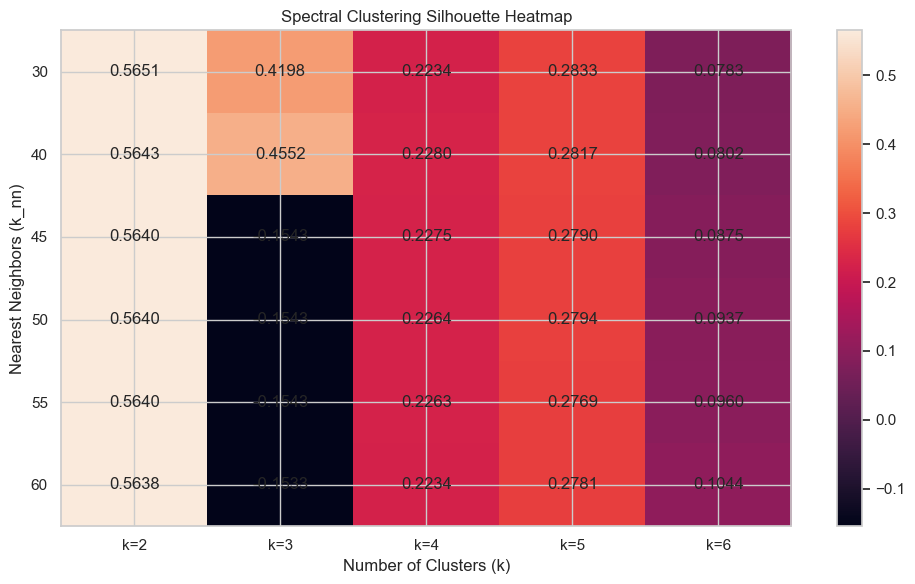

In [35]:
heatmap_data = df_spec_grid.set_index('k_nn')

# Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ heatmap
im = ax.imshow(
    heatmap_data.values,
    aspect='auto'
)

# Tick labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

# Labels
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Nearest Neighbors (k_nn)")
ax.set_title("Spectral Clustering Silhouette Heatmap")

# Hiện số trong từng ô
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):

        value = heatmap_data.iloc[i, j]

        if not np.isnan(value):
            ax.text(
                j,
                i,
                f"{value:.4f}",
                ha='center',
                va='center'
            )

# Colorbar
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [36]:
K_SPECTRAL   = 2
KNN_SPECTRAL = 45

spectral = SpectralClustering(
    n_clusters   = K_SPECTRAL,
    affinity     = 'nearest_neighbors',
    n_neighbors  = KNN_SPECTRAL,
    random_state = 42,
    n_init       = 10,
    n_jobs       = -1
)
labels_spec = spectral.fit_predict(X_model)

### 5b. Fit Spectral với tham số tối ưu

## 6. Tổng kết – Silhouette · DBI · CHI

In [37]:
def evaluate(labels, name):
    mask   = labels != -1          # loại bỏ noise của DBSCAN
    X_eval = X_model[mask]
    l_eval = labels[mask]
    n_clust = len(set(l_eval))
    if n_clust < 2:
        return {'Algorithm': name, 'N_Clusters': n_clust,
                'Silhouette': np.nan, 'DBI': np.nan, 'CHI': np.nan}
    return {
        'Algorithm'  : name,
        'N_Clusters' : n_clust,
        'Silhouette' : round(silhouette_score(X_eval, l_eval), 4),
        'DBI'        : round(davies_bouldin_score(X_eval, l_eval), 4),
        'CHI'        : round(calinski_harabasz_score(X_eval, l_eval), 2),
    }

df_summary = pd.DataFrame([
    evaluate(labels_kmeans, 'K-Means'),
    evaluate(labels_hc,     'Hierarchical'),
    evaluate(labels_db,     'DBSCAN'),
    evaluate(labels_spec,   'Spectral'),
    evaluate(labels_kmeans_8, 'K-Means_8'),
    evaluate(labels_db_7,     'DBSCAN_7'),
])
print(df_summary.to_string(index=False))


   Algorithm  N_Clusters  Silhouette    DBI     CHI
     K-Means           4      0.6343 0.6776 2719.68
Hierarchical           4      0.6288 0.7437 2552.71
      DBSCAN           2      0.7297 0.2548  278.88
    Spectral           2      0.5640 0.7661 1558.08
   K-Means_8           8      0.6338 0.6687 2646.20
    DBSCAN_7           7      0.7004 0.3396  239.58


## 9. DataFrame kết quả – cột `cluster_*` của từng model

In [16]:
df_clusters = df_raw.copy()
df_clusters['cluster_kmeans']       = labels_kmeans
df_clusters['cluster_kmeans_8']     = labels_kmeans_8
df_clusters['cluster_hierarchical'] = labels_hc
df_clusters['cluster_dbscan']       = labels_db
df_clusters['cluster_dbscan_7']     = labels_db_7
df_clusters['cluster_spectral']     = labels_spec

cluster_cols = ['cluster_kmeans', 'cluster_hierarchical',
                'cluster_dbscan', 'cluster_spectral',]

# Xem phân bố cụm từng model
for col in cluster_cols:
    print(f"\n{col}:")
    print(df_clusters[col].value_counts().sort_index().to_string())

df_clusters.head(10)




cluster_kmeans:
cluster_kmeans
0     788
1    3966
2     322
3      13

cluster_hierarchical:
cluster_hierarchical
0     425
1     804
2    3847
3      13

cluster_dbscan:
cluster_dbscan
-1     148
 0    4922
 1      19

cluster_spectral:
cluster_spectral
0     548
1     775
2     791
3      90
4    2885


,followerCnt,startingRate100k,recommendRate100k,followersGrowthRateRank,avgSixSecondsViewsRateRank,medianViewsRank,videoCompleteRateRank,engagementRateRank,avgSixSecondsViewsBenchMarkViews,medianBenchMarkViews,...,cov_view_recent,burstiness_recent,recency_days_recent,handleName,cluster_kmeans,cluster_kmeans_8,cluster_hierarchical,cluster_dbscan,cluster_dbscan_7,cluster_spectral
0,0.000000,-0.264363,-0.272189,0.000000,0.078531,8.472795,0.060136,-0.230721,18.211347,1.193833,...,0.956610,0.160784,-0.737646,nguyen_huynh_tien,1,7,0,0,0,1
1,0.827934,0.540219,0.220533,0.000000,0.000000,0.000000,0.000000,0.924174,0.000000,0.000000,...,1.119467,-0.008681,0.102047,khuyenduong299,0,2,1,0,0,2
2,0.000000,-0.264363,-0.272189,2.564664,0.000000,1.852253,0.011523,-0.230721,5.606685,0.000000,...,0.511231,-0.414296,-0.170552,n.huyen2k4,0,2,1,0,0,2
3,1.288772,1.003389,0.542573,0.000000,0.000000,0.000000,0.000000,0.736409,0.000000,0.000000,...,1.555191,-0.355080,-0.726124,stsonthach,0,2,1,0,0,2
4,0.000000,-0.264363,2.761453,0.000000,0.000000,4.769334,0.024530,-0.230721,15.250072,0.000000,...,0.771614,-0.054782,-0.202804,hoailinh_206,0,2,1,0,0,2
5,0.000000,-0.264363,-0.272189,35.786660,0.000000,0.691863,0.000000,-0.230721,0.771315,1.249887,...,0.930961,0.060771,-0.156039,qnhu.nhu.151,0,2,1,-1,-1,2
6,0.000000,-0.264363,-0.272189,0.000000,0.108373,0.000000,0.049582,5.896537,8.517700,0.000000,...,1.280589,0.025527,1.342817,msquynhthie,1,0,2,0,0,4
7,0.000000,-0.264363,-0.272189,0.000000,0.002994,0.259378,0.002705,0.157333,0.000000,0.000000,...,1.659759,-0.035939,-0.099856,thaybeou40,1,0,2,0,0,4
8,1.177538,0.809794,0.440221,0.000000,0.000000,0.000000,0.000000,1.092890,0.000000,0.000000,...,1.336509,-0.256221,-0.104187,vinhthichanngon,1,0,2,0,0,4
9,0.000000,-0.264363,-0.272189,7.255448,0.028676,5.585111,0.000000,-0.230721,28.579295,0.685088,...,0.915994,-0.075936,-0.538976,ninhanh01,2,7,0,0,0,1


In [ ]:
# df_clusters.to_csv("cluster_done.csv", index=False)